# Learned Forward-Backward Splitting for TGV² Tomography

This notebook evaluates an unrolled Forward-Backward Splitting (FBS) algorithm with **learned deviations** for TGV² image reconstruction from tomographic measurements.

At each iteration $n$, a CNN predicts deviation vectors $(u_n, v_n)$ that steer the algorithm toward faster convergence, subject to a safeguarding constraint that guarantees the Lyapunov decrease condition is preserved.

We compare two methods:
| Method | Description |
|---|---|
| **Zero deviations** | Base FBS algorithm — $u_n = v_n = 0$ at every step |
| **Learned FBS** | FBS with CNN-predicted deviations (our method) |

**Metrics evaluated:** KKT residual and PSNR vs. ground truth across iterations.

## 1 — Imports & Problem Setup

We load the problem parameters, build the operator structure (ray transform $A$, gradient $D$, symmetrised gradient $E$, resolvent $R_A$), and construct the train/test datasets of Shepp-Logan phantoms with random noise levels in $[0.05, 0.2]$.

Device: cuda
Train samples: 50 | Test samples: 10
KKT residual at clean image: 28.2584


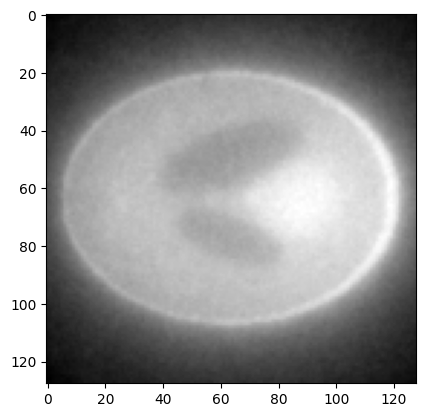

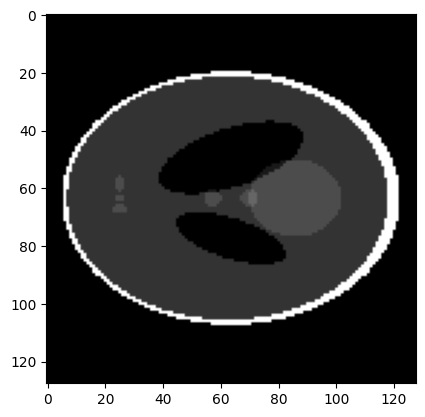

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys, os

sys.path.insert(0, os.path.abspath("."))  # NN_tomo lui-même
sys.path.append(os.path.abspath(".."))   # dossier parent Internship

from Algo_setuptorch import Params
from data.dataset import build_train_test_data
from algorithm.unrolled_model import UnrolledFBS
from algorithm.fbs_step import one_step
from plots import *
from run import *
from PSNR import psnr_history

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Problem parameters ────────────────────────────────────────────────────
params = Params()
size   = params.size

# Variable blocks: [primal u | dual p | dual q | dual r]
SHAPES = [
    (1, 1, size, size),   # u  — primal image
    (1, 2, size, size),   # p  — dual for Du - w  (2 channels: x, y)
    (1, 2, size, size),   # q
    (1, 3, size, size),   # r  — dual for Ew     (3 channels: xx, yy, xy)
]
N_CH_primal = sum(s[1] for s in SHAPES[:2])  # channels for u and p

# ── Dataset ───────────────────────────────────────────────────────────────
TRAIN_SEEDS = list(range(50))
TEST_SEEDS  = list(range(50, 60))

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)
print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")

# Pick the first test sample for all experiments
initial_state, clean, functions = test_data[0]

# Sanity check: KKT residual at the clean phantom
x_clean = [
    clean.to(device),
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 2, size, size), device=device),
    torch.zeros((1, 3, size, size), device=device),
]
print(f"KKT residual at clean image: {functions['kkt_residual_norm'](x_clean):.4f}")

img = initial_state.squeeze().cpu().detach().numpy()
plt.imshow(img, cmap='gray')  # cmap='gray' pour une image en niveaux de gris
plt.show()
img = clean.squeeze().cpu().detach().numpy()
plt.imshow(img, cmap='gray')  # cmap='gray' pour une image en niveaux de gris
plt.show()

## 2 — Load Trained Model

`UnrolledFBS` unrolls `T` iterations of FBS, with one shared `DeviationNet`. The checkpoint must have been saved with the full dict format (model + histories).

In [2]:
T = 200   # number of unrolled iterations (must match training)

model = UnrolledFBS(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=T,
    alpha=0.99,
).to(device).float()

checkpoint = torch.load("checkpoint_final_tomo_200epoch.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
model.eval()

train_hist = checkpoint["train_loss_history"]
val_hist   = checkpoint["val_loss_history"]

print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters")

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoint_final_tomo_200epoch.pt'

## 3 — Training History

Loss $= \sum_t w_t \|\text{KKT residual}_t\|$ (weighted sum with increasing weights), averaged over training samples.

In [ ]:
plt.figure(figsize=(9, 4))
plt.semilogy(train_hist, label="Train loss",      color="royalblue",  linewidth=2)
plt.semilogy(val_hist,   label="Validation loss", color="darkorange", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training history — TGV² tomography")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("loss_history_tomo.png", dpi=150)
plt.show()

## 4 — Convergence Analysis

We run both FBS variants for 100 iterations and plot two convergence indicators on a log-log scale:

- **KKT residual** $\|r_n\|$ — distance to the optimality conditions of the TGV² inclusion

Dashed lines show the theoretical rates $O(1/t)$ and $O(1/t^2)$ for reference.

In [3]:
T_test = 100

# Zero-deviation baseline (u_n = v_n = 0 for all n)
F_vals_0, res_0, x_hist = run_zero(initial_state, functions, params, SHAPES, T_test, device)

# Learned FBS (CNN-predicted deviations)
#F_vals_CNN, res_CNN, history = run_learned(model, initial_state, clean, functions, T_test=T_test, return_all=True)

iter:0
218188.875
iter:1
194392.484375
iter:2
173196.109375
iter:3
154315.9375
iter:4
137499.15625
iter:5
122520.5390625
iter:6
109179.4921875
iter:7
97297.3046875
iter:8
86714.8203125
iter:9
77290.25
iter:10
68897.3046875
iter:11
61423.4765625
iter:12
54768.57421875
iter:13
48843.34765625
iter:14
43568.30078125
iter:15
38872.625
iter:16
34693.26171875
iter:17
30974.044921875
iter:18
27664.939453125
iter:19
24721.39453125
iter:20
22103.720703125
iter:21
19776.5703125
iter:22
17708.453125
iter:23
15871.322265625
iter:24
14240.177734375
iter:25
12792.7392578125
iter:26
11509.1435546875
iter:27
10371.666015625
iter:28
9364.484375
iter:29
8473.458984375
iter:30
7685.93994140625
iter:31
6990.5966796875
iter:32
6377.2607421875
iter:33
5836.7978515625
iter:34
5360.984375
iter:35
4942.41259765625
iter:36
4574.40087890625
iter:37
4250.923828125
iter:38
3966.551025390625
iter:39
3716.399169921875
iter:40
3496.087890625
iter:41
3301.70703125
iter:42
3129.7783203125
iter:43
2977.22998046875
iter:4

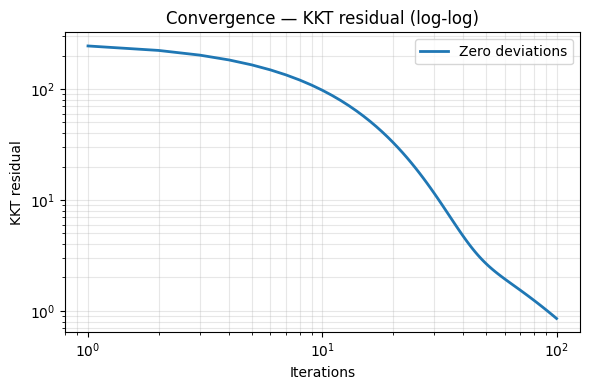

In [4]:
# ── KKT residual ──────────────────────────────────────────────────────────
res_0   = np.array(res_0)
##res_CNN = np.array(res_CNN)
iters   = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6, 4))
plt.loglog(iters, res_0,   label="Zero deviations",    linewidth=2)
#plt.loglog(iters, res_CNN, label="Learned deviations", linewidth=2)
#plt.loglog(iters, res_0[0] / iters,    "k--", label=r"$O(1/t)$")
#plt.loglog(iters, res_0[0] / iters**2, "k-.", label=r"$O(1/t^2)$")
plt.xlabel("Iterations")
plt.ylabel("KKT residual")
plt.title("Convergence — KKT residual (log-log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

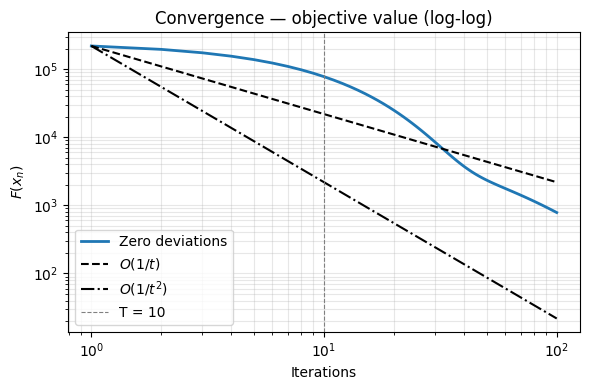

In [5]:
# ── Objective value F(x_n) ────────────────────────────────────────────────
def to_numpy(vals):
    return np.array([
        v.detach().cpu().item() if torch.is_tensor(v) else float(v)
        for v in vals
    ])

gap_0   = np.maximum(to_numpy(F_vals_0),   1e-16)
#gap_CNN = np.maximum(to_numpy(F_vals_CNN), 1e-16)
iters   = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6, 4))
plt.loglog(iters, gap_0,   label="Zero deviations",    linewidth=2)
#plt.loglog(iters, gap_CNN, label="Learned deviations", linewidth=2)
plt.loglog(iters, gap_0[0] / iters,    "k--", label=r"$O(1/t)$")
plt.loglog(iters, gap_0[0] / iters**2, "k-.", label=r"$O(1/t^2)$")

plt.axvline(x=10, color="gray", linewidth=0.8, linestyle="--", label=f"T = {10}")
plt.xlabel("Iterations")
plt.ylabel(r"$F(x_n)$")
plt.title("Convergence — objective value (log-log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — PSNR Comparison

We compare reconstruction quality (PSNR relative to the ground-truth Shepp-Logan phantom $x^*$) across both methods at each iteration.

Both methods are initialised from the same backprojection $A^T y$ so the starting PSNR is identical.

In [6]:
# ── Zero deviations — collect per-iteration primal iterates ───────────────
psnr_zero = psnr_history(x_hist, clean)

# ── Learned FBS — PSNR from stored iteration history ─────────────────────
#psnr_learned = psnr_history(history["x"], clean)

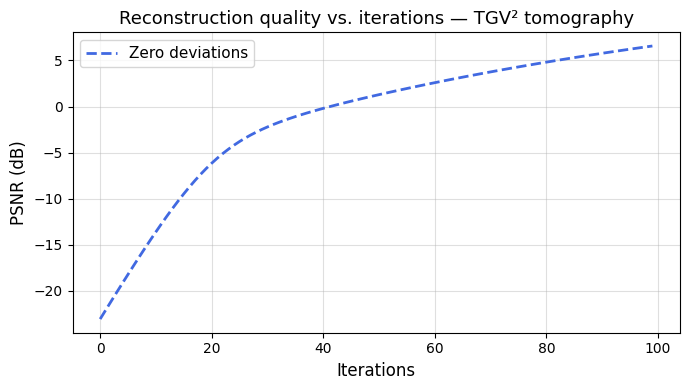


PSNR after 100 iterations:
  Zero deviations : 6.57 dB


In [7]:
plt.figure(figsize=(7, 4))
#plt.plot(psnr_learned, label="Learned FBS",     color="crimson",   linewidth=2)
plt.plot(psnr_zero,    label="Zero deviations", color="royalblue", linewidth=2, linestyle="--")
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("PSNR (dB)",  fontsize=12)
plt.title("Reconstruction quality vs. iterations — TGV² tomography", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("comparison_psnr_tomo.pdf", bbox_inches="tight")
plt.show()

print(f"\nPSNR after {T_test} iterations:")
print(f"  Zero deviations : {psnr_zero[-1]:.2f} dB")
#print(f"  Learned FBS     : {psnr_learned[-1]:.2f} dB  ({psnr_learned[-1]-psnr_zero[-1]:+.2f} dB)")

## 6 — Visual Reconstruction

Side-by-side comparison of the reconstructed images after `T_test` iterations.

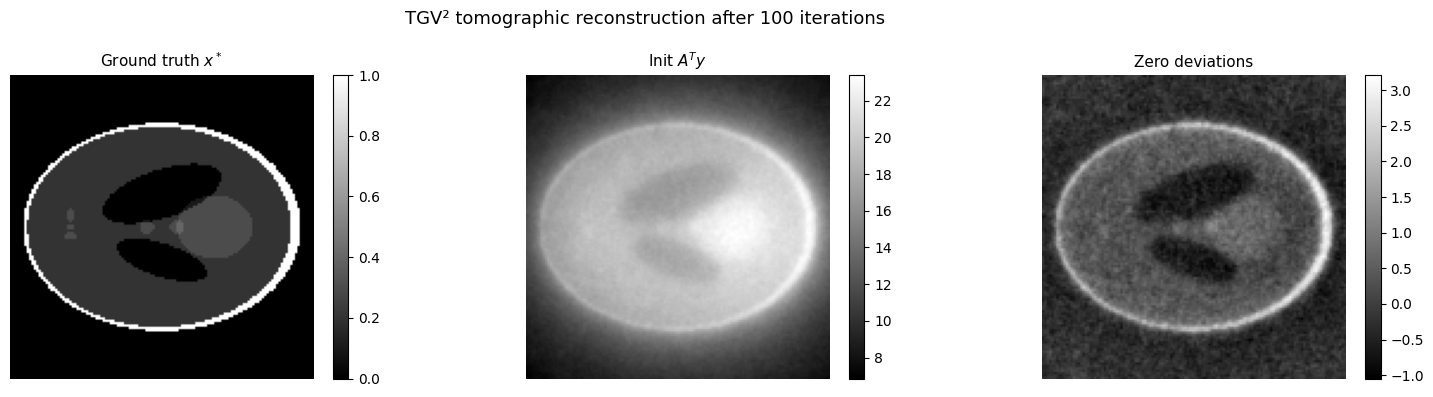

In [8]:
# Extract final reconstructions
u_zero = x_hist[-1][0].squeeze().cpu().detach().numpy()
#u_learned = history["x"][-1][0].squeeze().cpu().numpy()
u_true    = clean.squeeze().cpu().numpy()
u_init    = initial_state.squeeze().cpu().numpy()

vmin, vmax = u_true.min(), u_true.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ["Ground truth $x^*$", "Init $A^T y$", "Zero deviations", "Learned FBS"]
imgs   = [u_true, u_init, u_zero]

for ax, img, title in zip(axes, imgs, titles):
    im = ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"TGV² tomographic reconstruction after {T_test} iterations", fontsize=13)
plt.tight_layout()
plt.savefig("reconstruction_tomo.pdf", bbox_inches="tight", dpi=150)
plt.show()